# Comparação de variantes do pipeline no conjunto de teste

## Objetivo

Compara threshold normal/fuzzy e segmentação RG/FC, incluindo métricas, pares de exames e exemplos qualitativos 3D.

In [1]:
from pathlib import Path
import copy
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    from utils.project.notebook_env import configure_notebook_environment
    REPO_ROOT = configure_notebook_environment(chdir_to_src=False)
except Exception:
    current = Path.cwd().resolve()
    REPO_ROOT = next(
        path for path in [current, *current.parents]
        if (path / "src").exists() and (path / "output").exists()
    )

SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utils.project.config import load_config_json
from utils.project.notebook_env import resolve_imagecas_base_path
from utils.experiments import run_qualitative_pipeline_case
from utils.visualization.volume import (
    visualize_aorta_ostia_artery,
)

from utils.visualization.variant_comparison import (
    best_variant_by_suffix,
    build_dice_stats_by_variant,
    build_delta_summary_vs_reference,
    build_pair_outcome_counts,
    build_ranking_table,
    largest_pair_changes,
    load_variant_results,
    pair_summary,
    plot_largest_pair_changes,
    plot_ostia_status_by_variant,
    plot_pair_delta_by_image,
    plot_pair_dice_by_image,
    select_qualitative_pair_cases,
)

RESULT_ROOT = REPO_ROOT / "output/segmentation/runs/mid_res/fuzzy_comparison"
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
RESULT_ROOT


PosixPath('/home/matheus/workspace/coronary-centerline-detection/output/segmentation/runs/mid_res/fuzzy_comparison')

## Configuração

Ajuste nesta seção apenas os parâmetros da análise; o pipeline base não é alterado.

## Carregamento dos Resultados

A análise usa o `ostios_test_summary.csv` de cada variante como fonte principal, porque esse CSV registra por imagem o método de threshold e o método arterial efetivamente usados.

In [2]:
PREFERRED_ORDER = [
    "normal_rg",
    "th_fuzzy_rg",
    "normal_fc",
    "th_fuzzy_fc",
]

PRETTY_NAMES = {
    "normal_rg": "Normal + RG",
    "th_fuzzy_rg": "Fuzzy threshold + RG",
    "normal_fc": "Normal + FC",
    "th_fuzzy_fc": "Fuzzy threshold + FC",
}

ANALYSIS_SPLIT = "test"

In [3]:
results_df, summary_df = load_variant_results(
    RESULT_ROOT,
    split=ANALYSIS_SPLIT,
    preferred_order=PREFERRED_ORDER,
    pretty_names=PRETTY_NAMES,
    repo_root=REPO_ROOT,
)

print(f"Split analisado: {ANALYSIS_SPLIT}")
print(f"Runs carregados: {summary_df.shape[0]}")
print(f"Linhas por imagem: {results_df.shape[0]}")

Split analisado: test
Runs carregados: 4
Linhas por imagem: 2800


In [4]:
display(summary_df)

,folder_variant,variant_label,run_timestamp,run_dir,n_images,threshold_mode,artery_method,ostia_detected_rate,ostia_success_rate,both_correct_n,both_tolerable_n,found_wrong_n,not_found_or_error_n,mean_dice,median_dice,std_dice,mean_dice_success_ostia,result_root
0,normal_rg,Normal + RG,2026-06-22_10-18-31,output/segmentation/runs/mid_res/fuzzy_compari...,700,normal,rg,0.994286,0.808571,60,506,130,4,0.578427,0.652087,0.196185,0.649271,/home/matheus/workspace/coronary-centerline-de...
1,th_fuzzy_rg,Fuzzy threshold + RG,2026-06-20_08-33-25,output/segmentation/runs/mid_res/fuzzy_compari...,700,fuzzy,rg,0.990000,0.808571,51,515,127,7,0.580936,0.653493,0.195601,0.651245,/home/matheus/workspace/coronary-centerline-de...
2,normal_fc,Normal + FC,2026-06-19_09-20-42,output/segmentation/runs/mid_res/fuzzy_compari...,700,normal,fc,0.994286,0.808571,60,506,130,4,0.564721,0.636069,0.193130,0.631494,/home/matheus/workspace/coronary-centerline-de...
3,th_fuzzy_fc,Fuzzy threshold + FC,2026-06-20_23-26-14,output/segmentation/runs/mid_res/fuzzy_compari...,700,fuzzy,fc,0.990000,0.808571,51,515,127,7,0.562797,0.637484,0.193844,0.627929,/home/matheus/workspace/coronary-centerline-de...


## Análise

As subseções abaixo apresentam as métricas, tabelas ou visualizações do objetivo definido.

## Resumo Geral

A tabela abaixo ordena as variantes por sucesso dos óstios e Dice médio. O sucesso dos óstios considera `both correct` ou `both tolerable` como sucesso.

In [5]:
ranking_df = summary_df.sort_values(
    ["ostia_success_rate", "mean_dice", "mean_dice_success_ostia"],
    ascending=False,
).copy()
ranking_display = build_ranking_table(summary_df)

for col in ["ostia_detected_rate", "ostia_success_rate"]:
    if col in ranking_display.columns:
        ranking_display[col] = 100 * ranking_display[col]

In [6]:
display(ranking_display.round({
    "ostia_detected_rate": 1,
    "ostia_success_rate": 1,
    "mean_dice": 4,
    "median_dice": 4,
    "mean_dice_success_ostia": 4,
}))

,variant_label,threshold_mode,artery_method,n_images,ostia_detected_rate,ostia_success_rate,both_correct_n,both_tolerable_n,found_wrong_n,not_found_or_error_n,mean_dice,median_dice,mean_dice_success_ostia
1,Fuzzy threshold + RG,fuzzy,rg,700,99.0,80.9,51,515,127,7,0.5809,0.6535,0.6512
0,Normal + RG,normal,rg,700,99.4,80.9,60,506,130,4,0.5784,0.6521,0.6493
2,Normal + FC,normal,fc,700,99.4,80.9,60,506,130,4,0.5647,0.6361,0.6315
3,Fuzzy threshold + FC,fuzzy,fc,700,99.0,80.9,51,515,127,7,0.5628,0.6375,0.6279


## Detecção dos Óstios

Aqui o status é separado em: ambos corretos, ambos toleráveis, encontrados porém incorretos e não encontrado/erro.

In [7]:
ostia_plot = summary_df.copy()

Figura salva em: output/segmentation/analysis/threshold_pipeline_comparison/figures/ostia_status_by_variant.png


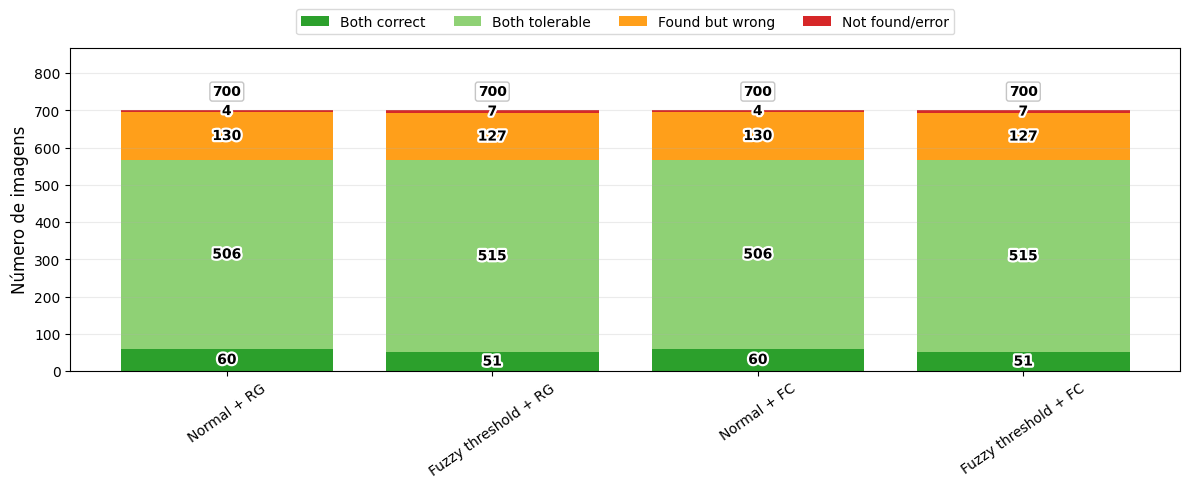

In [8]:
plot_ostia_status_by_variant(
    ostia_plot,
    preferred_order=PREFERRED_ORDER,
    pretty_names=PRETTY_NAMES,
    save_path=None,
)
plt.show()

## Dice Score por Variante

A tabela abaixo resume o Dice arterial por variante. O gráfico em seguida mostra média e mediana para comparação visual.

In [9]:
dice_plot = summary_df.copy()
dice_plot["variant_label"] = pd.Categorical(
    dice_plot["variant_label"],
    [PRETTY_NAMES.get(name, name) for name in PREFERRED_ORDER],
    ordered=True,
)
dice_plot = dice_plot.sort_values("variant_label")

In [10]:
dice_stats_df = build_dice_stats_by_variant(results_df, PREFERRED_ORDER)

display(dice_stats_df.round({
    "mean_dice": 4,
    "max_dice": 4,
    "min_dice": 4,
    "std_dice": 4,
    "median_dice": 4,
}))

CSV salvo em: output/segmentation/analysis/threshold_pipeline_comparison/tables/dice_stats_by_variant.csv


,folder_variant,variant_label,mean_dice,max_dice,min_dice,std_dice,median_dice
0,normal_rg,Normal + RG,0.5784,0.8311,0.0,0.1962,0.6521
1,th_fuzzy_rg,Fuzzy threshold + RG,0.5809,0.8302,0.0,0.1956,0.6535
2,normal_fc,Normal + FC,0.5647,0.8155,0.0,0.1931,0.6361
3,th_fuzzy_fc,Fuzzy threshold + FC,0.5628,0.8154,0.0,0.1938,0.6375


Figura salva em: output/segmentation/analysis/threshold_pipeline_comparison/figures/dice_mean_median_by_variant.png


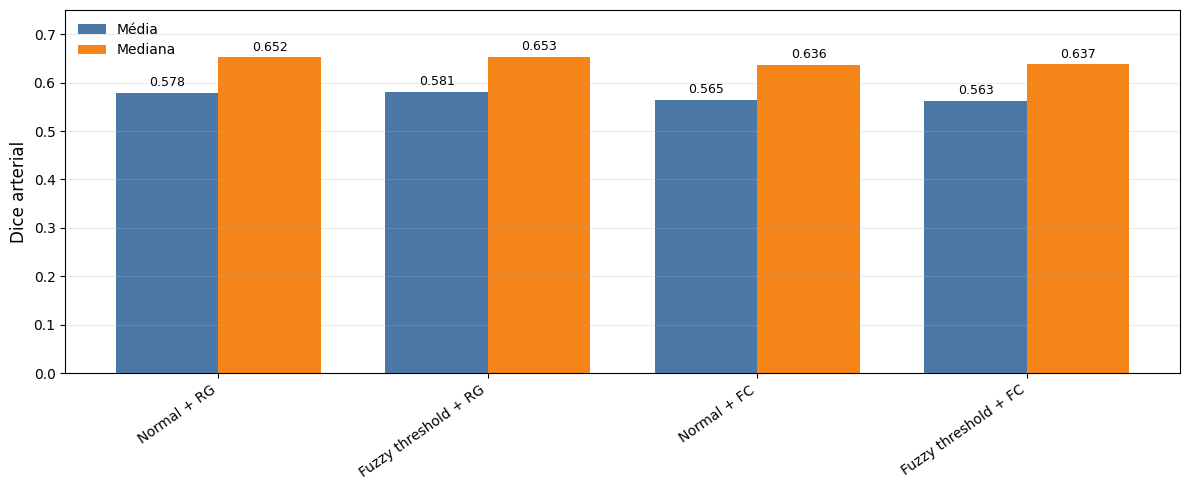

In [11]:
x = np.arange(len(dice_plot))
width = 0.38
fig, ax = plt.subplots(figsize=(12, 5))
mean_bars = ax.bar(x - width/2, dice_plot["mean_dice"], width, label="Média", color="#4c78a8")
median_bars = ax.bar(x + width/2, dice_plot["median_dice"], width, label="Mediana", color="#f58518")

for bars in [mean_bars, median_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.008,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_xticks(x)
ax.set_xticklabels(dice_plot["variant_label"].astype(str), rotation=35, ha="right")
ax.set_ylabel("Dice arterial", fontsize=12)
y_max = max(0.75, float(dice_plot[["mean_dice", "median_dice"]].max().max()) + 0.08)
ax.set_ylim(0, y_max)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Comparação com Baseline

A célula abaixo usa `Normal + RG` como baseline e calcula o ganho/perda de Dice por imagem.

In [12]:
baseline_variant = "normal_rg"
delta_summary_df = build_delta_summary_vs_reference(
    results_df,
    baseline_variant,
    variants=PREFERRED_ORDER,
    pretty_names=PRETTY_NAMES,
)

In [13]:
display(delta_summary_df.round({
    "mean_delta": 4,
    "median_delta": 4,
    "max_gain": 4,
    "max_loss": 4,
}))

,folder_variant,variant_label,mean_delta,median_delta,variant_better_by_0_02_n,reference_better_by_0_02_n,max_gain,max_loss
0,th_fuzzy_rg,Fuzzy threshold + RG,0.0025,0.0001,78,62,0.7976,-0.7349
1,normal_fc,Normal + FC,-0.0137,-0.0077,89,212,0.3198,-0.3780
2,th_fuzzy_fc,Fuzzy threshold + FC,-0.0156,-0.0094,123,256,0.7917,-0.7349


Figura salva em: output/segmentation/analysis/threshold_pipeline_comparison/figures/dice_delta_vs_normal_rg.png


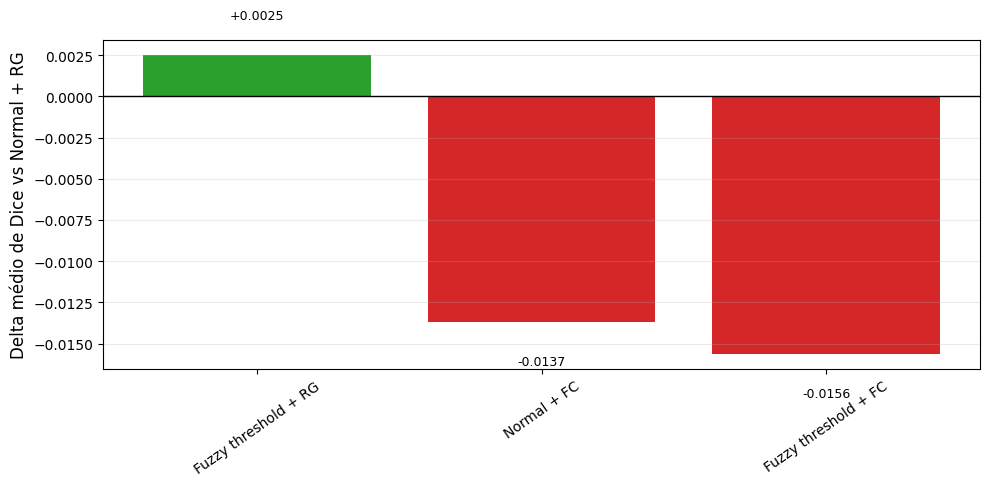

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_delta = delta_summary_df.copy()
colors = ["#2ca02c" if value >= 0 else "#d62728" for value in plot_delta["mean_delta"]]
bars = ax.bar(plot_delta["variant_label"], plot_delta["mean_delta"], color=colors)

for bar, value in zip(bars, plot_delta["mean_delta"]):
    va = "bottom" if value >= 0 else "top"
    offset = 0.002 if value >= 0 else -0.002
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + offset,
        f"{value:+.4f}",
        ha="center",
        va=va,
        fontsize=9,
    )

ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Delta médio de Dice vs Normal + RG", fontsize=12)
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=35, labelsize=10)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### Melhor Resultado vs Pipeline Original

A análise usa exclusivamente o conjunto de teste. A melhor variante não baseline é selecionada pelo ranking geral e os exames comuns são ordenados por `IMG_ID`. No primeiro gráfico, a melhor variante aparece no painel superior e o pipeline original no inferior; os dois usam a mesma escala de Dice entre 0 e 1. Para o delta, valores positivos favorecem a melhor variante.

In [15]:
BEST_COMPARISON_VARIANT = next(
    variant
    for variant in ranking_df["folder_variant"].astype(str)
    if variant != baseline_variant
)
DICE_PANEL_NAMES = {
    baseline_variant: "Baseline",
    BEST_COMPARISON_VARIANT: "C2",
}
print(f"Melhor variante: {PRETTY_NAMES.get(BEST_COMPARISON_VARIANT, BEST_COMPARISON_VARIANT)}")

Melhor variante: Fuzzy threshold + RG
Tabela salva em: output/segmentation/analysis/threshold_pipeline_comparison/tables/best_variant_vs_baseline_auc.csv


,curve,variant,variant_label,n_images,auc,normalized_auc
0,reference,normal_rg,Normal + RG,700,404.2104,0.5783
1,comparison,th_fuzzy_rg,Fuzzy threshold + RG,700,405.9652,0.5808
2,delta,th_fuzzy_rg_minus_normal_rg,Fuzzy threshold + RG - Normal + RG,700,1.7548,0.0025


Figura salva em: output/segmentation/analysis/threshold_pipeline_comparison/figures/dice_by_image_best_variant_vs_baseline.png


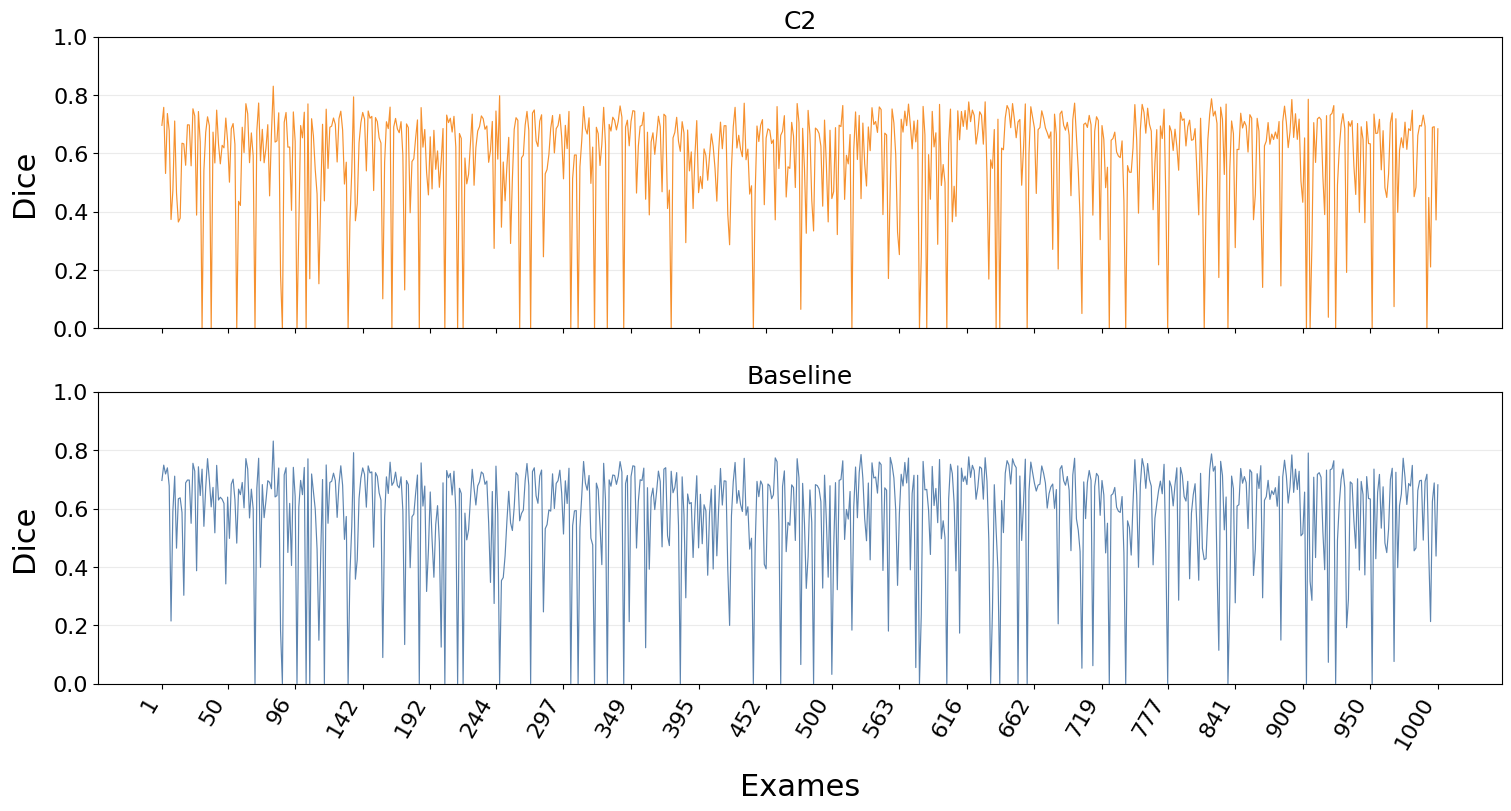

In [16]:
plot_pair_dice_by_image(
    results_df,
    baseline_variant,
    BEST_COMPARISON_VARIANT,
    pretty_names=DICE_PANEL_NAMES,
    save_path=None,
)
plt.show()

Figura salva em: output/segmentation/analysis/threshold_pipeline_comparison/figures/dice_delta_by_image_best_variant_vs_baseline.png


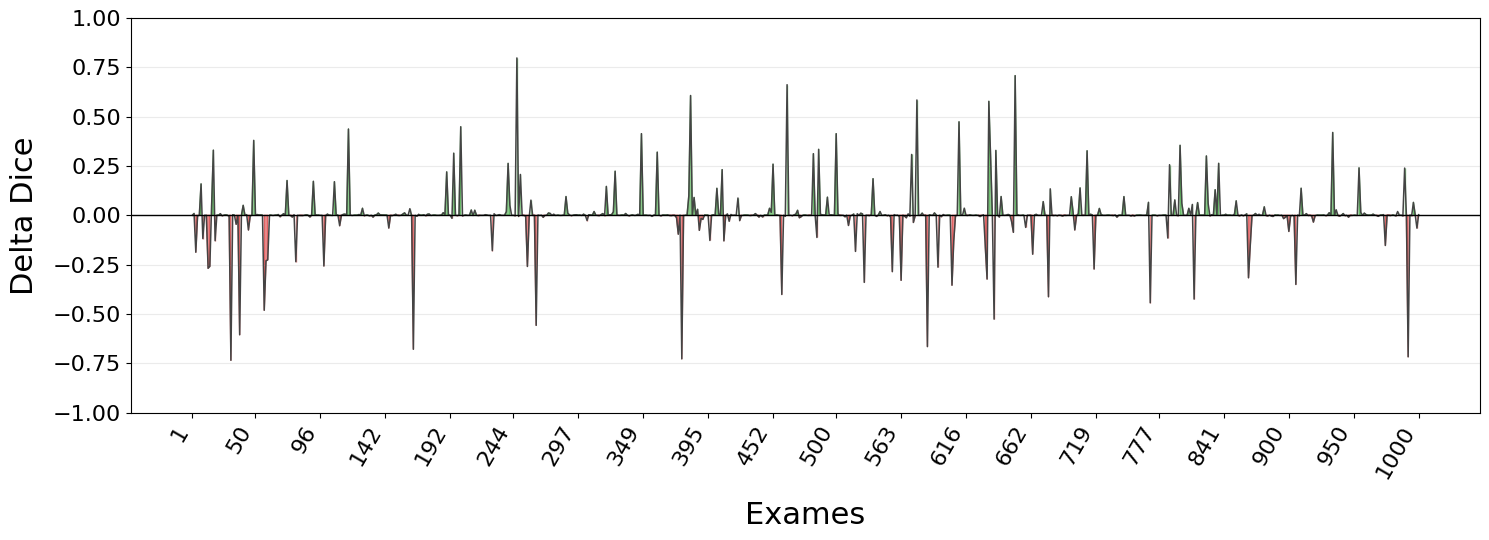

In [17]:
plot_pair_delta_by_image(
    results_df,
    baseline_variant,
    BEST_COMPARISON_VARIANT,
    pretty_names=PRETTY_NAMES,
    save_path=None,
)
plt.show()

In [18]:
results_df

,IMG_ID,artery_dice,artery_voxel_count,artery_segmentation_method,fc_processed_voxels,fc_effective_alpha,fc_object_seed_count,fc_candidate_voxels_final,threshold_mode,contextual_apply_to,threshold_voxel_count,lcc_voxel_count,mean_contextual_weight,ostia_detected,ostia_detection_status,artery_segmentation_run,segmented_with_incorrect_ostia,segmentation_skip_reason,ostia_detection_error,both_ostia_correct,both_ostia_tolerable,left_ostium_correct,right_ostium_correct,left_ostium_distance_mm,right_ostium_distance_mm,left_ostium,right_ostium,pipeline_error,status,downscale_method,opencv_interpolation,downscale_factors,max_threshold_percentile,lcc_per_slice,lcc_mode,configured_artery_segmentation_method,aorta_miss_count,aorta_out_of_tolerance_as_miss,aorta_interpolate_missed_circles,folder_variant,variant_label,run_timestamp,run_dir,ostia_detected_bool,ostia_success,both_correct,both_tolerable,found_wrong
0,568,0.660527,34653.0,fuzzy_connectedness,9144.0,0.16,8.0,279112.0,normal,none,NaN,NaN,NaN,yes,both tolerable,yes,no,NaN,NaN,no,yes,no,no,1.367188,0.500000,"(90, 119, 141)","(92, 82, 166)",NaN,both ostia tolerable,opencv,linear,"(2, 2, 1)",99.7,yes,per_slice,fc,5,no,yes,normal_fc,Normal + FC,2026-06-19_09-20-42,output/segmentation/runs/mid_res/fuzzy_compari...,True,True,False,True,False
1,762,0.404692,12727.0,fuzzy_connectedness,3247.0,0.16,8.0,466598.0,normal,none,NaN,NaN,NaN,yes,both tolerable,yes,no,NaN,NaN,no,yes,yes,no,0.000000,2.119996,"(96, 169, 183)","(144, 88, 195)",NaN,both ostia tolerable,opencv,linear,"(2, 2, 1)",99.7,yes,per_slice,fc,5,no,yes,normal_fc,Normal + FC,2026-06-19_09-20-42,output/segmentation/runs/mid_res/fuzzy_compari...,True,True,False,True,False
2,765,0.583574,24604.0,fuzzy_connectedness,5955.0,0.16,8.0,487945.0,normal,none,NaN,NaN,NaN,yes,both tolerable,yes,no,NaN,NaN,no,yes,no,yes,2.039062,0.000000,"(101, 160, 173)","(126, 124, 207)",NaN,both ostia tolerable,opencv,linear,"(2, 2, 1)",99.7,yes,per_slice,fc,5,no,yes,normal_fc,Normal + FC,2026-06-19_09-20-42,output/segmentation/runs/mid_res/fuzzy_compari...,True,True,False,True,False
3,693,0.659479,28330.0,fuzzy_connectedness,7615.0,0.16,8.0,314523.0,normal,none,NaN,NaN,NaN,yes,both tolerable,yes,no,NaN,NaN,no,yes,no,no,0.809574,0.809574,"(95, 166, 148)","(118, 126, 176)",NaN,both ostia tolerable,opencv,linear,"(2, 2, 1)",99.7,yes,per_slice,fc,5,no,yes,normal_fc,Normal + FC,2026-06-19_09-20-42,output/segmentation/runs/mid_res/fuzzy_compari...,True,True,False,True,False
4,469,0.499774,13851.0,fuzzy_connectedness,3643.0,0.16,8.0,500000.0,normal,none,NaN,NaN,NaN,yes,both tolerable,yes,no,NaN,NaN,no,yes,no,no,2.371708,0.500000,"(96, 175, 125)","(110, 148, 162)",NaN,both ostia tolerable,opencv,linear,"(2, 2, 1)",99.7,yes,per_slice,fc,5,no,yes,normal_fc,Normal + FC,2026-06-19_09-20-42,output/segmentation/runs/mid_res/fuzzy_compari...,True,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,334,0.723920,40316.0,region_growing,NaN,NaN,NaN,NaN,fuzzy,none,9726531.0,9562324.0,0.695535,yes,both tolerable,yes,no,NaN,NaN,no,yes,yes,no,0.000000,0.500000,"(85, 164, 158)","(108, 124, 202)",NaN,both ostia tolerable,opencv,linear,"(2, 2, 1)",99.7,yes,per_slice,rg,5,no,yes,th_fuzzy_rg,Fuzzy threshold + RG,2026-06-20_08-33-25,output/segmentation/runs/mid_res/fuzzy_compari...,True,True,False,True,False
2796,648,0.717200,21875.0,region_growing,NaN,NaN,NaN,NaN,fuzzy,none,12748545.0,12624624.0,0.730041,yes,both tolerable,yes,no,NaN,NaN,no,yes,no,no,1.477957,0.500000,"(94, 150, 168)","(104, 118, 207)",NaN,both ostia tolerable,opencv,linear,"(2, 2, 1)",99.7,yes,per_slice,rg,5,no,yes,th_fuzzy_rg,Fuzzy threshold + RG,2026-06-20_08-33-25,output/segmentation/runs/mid_res/fuzzy_compari...,True,True,False,True,False
2797,366,0.596669,40150.0,region_growing,NaN,NaN,NaN,NaN,fuzzy,none,11689301.0,11215709.0,0.673403,yes,bo

## Maiores Variações por Comparação

As próximas células comparam pares específicos de variantes. Em cada comparação, o delta é calculado como `comparação - referência`. Valores positivos indicam que a segunda variante melhorou o Dice em relação à primeira.

In [19]:
PAIR_COMPARISONS = None
print("Os pares são gerados automaticamente a partir das variantes carregadas.")

Os pares são gerados automaticamente a partir das variantes carregadas.


### Resumo Numérico das Variações

Legenda das variantes: `C1 = Normal + RG`, `C2 = Fuzzy threshold + RG`, `C3 = Normal + FC`, `C4 = Fuzzy threshold + FC`.

A tabela abaixo mostra, para cada comparação, quantos exames melhoraram, pioraram ou ficaram com o mesmo Dice em relação à variante de referência. O delta é calculado como `comparação - referência`.


In [20]:
pair_outcome_counts_df = build_pair_outcome_counts(
    results_df,
    PAIR_COMPARISONS,
    pretty_names=PRETTY_NAMES,
    min_delta=0.02,
    variant_order=PREFERRED_ORDER,
)

compact_pair_outcome_counts_df = pair_outcome_counts_df[
    [
        "comparison_name",
        "n_images",
        "comparison_better_n",
        "reference_better_n",
        "same_dice_n",
        "mean_delta",
    ]
]

display(compact_pair_outcome_counts_df.round({
    "mean_delta": 4,
}))

,comparison_name,n_images,comparison_better_n,reference_better_n,same_dice_n,mean_delta
0,Fuzzy threshold + RG vs Normal + RG,700,400,269,31,0.0025
1,Normal + FC vs Normal + RG,700,215,451,34,-0.0137
2,Fuzzy threshold + FC vs Normal + RG,700,221,452,27,-0.0156
3,Normal + FC vs Fuzzy threshold + RG,700,208,464,28,-0.0162
4,Fuzzy threshold + FC vs Fuzzy threshold + RG,700,209,455,36,-0.0181
5,Fuzzy threshold + FC vs Normal + FC,700,367,298,35,-0.0019


CSV salvo em: output/segmentation/analysis/threshold_pipeline_comparison/tables/pair_outcome_counts.csv


### Threshold fuzzy vs normal, ambos com RG

In [21]:
display(pair_summary(results_df, "normal_rg", "th_fuzzy_rg", PRETTY_NAMES).round({"mean_delta": 4, "median_delta": 4, "max_gain": 4, "max_loss": 4}))

,reference,comparison,n_images,mean_delta,median_delta,comparison_better_by_0_02_n,reference_better_by_0_02_n,max_gain,max_loss
0,Normal + RG,Fuzzy threshold + RG,700,0.0025,0.0001,78,62,0.7976,-0.7349


In [22]:
display(largest_pair_changes(results_df, "normal_rg", "th_fuzzy_rg", top_n=10).round({"reference_dice": 4, "comparison_dice": 4, "dice_delta": 4}))

,IMG_ID,reference_dice,comparison_dice,dice_delta,reference_ostia_status,comparison_ostia_status,same_ostia_points,reference_left_ostium,comparison_left_ostium,reference_right_ostium,comparison_right_ostium,reference_artery_voxels,comparison_artery_voxels
364,246,0.0000,0.7976,0.7976,found but incorrect,both correct,False,"(124, 189, 232)","(101, 163, 170)","(160, 161, 221)","(136, 139, 203)",602.0,28495.0
510,33,0.7349,0.0000,-0.7349,both tolerable,found but incorrect,False,"(114, 167, 176)","(109, 160, 188)","(119, 119, 195)","(134, 129, 166)",30683.0,1661.0
79,375,0.7277,0.0000,-0.7277,both tolerable,found but incorrect,False,"(107, 161, 165)","(54, 127, 262)","(116, 117, 179)","(61, 114, 263)",25584.0,534.0
662,993,0.7174,0.0000,-0.7174,both correct,found but incorrect,False,"(88, 146, 173)","(71, 147, 250)","(114, 103, 200)","(70, 117, 176)",41600.0,6009.0
198,650,0.0000,0.7079,0.7079,found but incorrect,both tolerable,False,"(124, 159, 218)","(102, 160, 147)","(107, 100, 220)","(110, 126, 179)",0.0,28204.0
139,163,0.6793,0.0003,-0.6790,both tolerable,found but incorrect,False,"(88, 151, 164)","(90, 152, 175)","(105, 128, 211)","(108, 122, 134)",26746.0,773.0
201,580,0.6655,0.0000,-0.6655,both tolerable,found but incorrect,False,"(88, 162, 155)","(89, 160, 168)","(106, 124, 185)","(84, 126, 131)",24307.0,348.0
396,463,0.0000,0.6621,0.6621,found but incorrect,both tolerable,False,"(64, 161, 190)","(99, 155, 138)","(103, 143, 180)","(113, 121, 173)",12090.0,43868.0
335,383,0.0000,0.6070,0.6070,found but incorrect,both tolerable,False,"(49, 109, 270)","(95, 152, 154)","(49, 104, 266)","(116, 114, 190)",441.0,17043.0
255,39,0.6056,0.0000,-0.6056,both tolerable,not found,False,"(117, 157, 140)",NaN,"(121, 119, 182)",NaN,44055.0,NaN


Figura salva em: output/segmentation/analysis/threshold_pipeline_comparison/figures/largest_changes_th_fuzzy_rg_vs_normal_rg.png


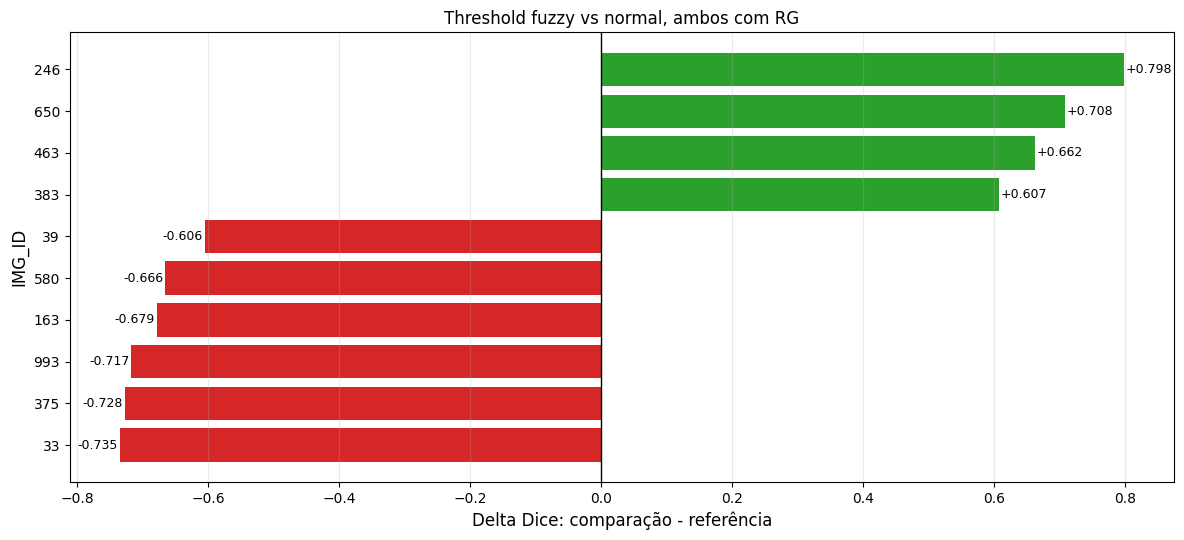

In [23]:
plot_largest_pair_changes(
    results_df,
    "normal_rg",
    "th_fuzzy_rg",
    title="Threshold fuzzy vs normal, ambos com RG",
    save_path=None,
    top_n=10,
)
plt.show()

### Threshold fuzzy vs normal, ambos com FC

In [24]:
display(pair_summary(results_df, "normal_fc", "th_fuzzy_fc", PRETTY_NAMES).round({"mean_delta": 4, "median_delta": 4, "max_gain": 4, "max_loss": 4}))

,reference,comparison,n_images,mean_delta,median_delta,comparison_better_by_0_02_n,reference_better_by_0_02_n,max_gain,max_loss
0,Normal + FC,Fuzzy threshold + FC,700,-0.0019,0.0,65,72,0.7917,-0.7396


In [25]:
display(largest_pair_changes(results_df, "normal_fc", "th_fuzzy_fc", top_n=10).round({"reference_dice": 4, "comparison_dice": 4, "dice_delta": 4}))

,IMG_ID,reference_dice,comparison_dice,dice_delta,reference_ostia_status,comparison_ostia_status,same_ostia_points,reference_left_ostium,comparison_left_ostium,reference_right_ostium,comparison_right_ostium,reference_artery_voxels,comparison_artery_voxels
364,246,0.0000,0.7917,0.7917,found but incorrect,both correct,False,"(124, 189, 232)","(101, 163, 170)","(160, 161, 221)","(136, 139, 203)",352.0,28715.0
510,33,0.7396,0.0000,-0.7396,both tolerable,found but incorrect,False,"(114, 167, 176)","(109, 160, 188)","(119, 119, 195)","(134, 129, 166)",29058.0,1109.0
79,375,0.7313,0.0000,-0.7313,both tolerable,found but incorrect,False,"(107, 161, 165)","(54, 127, 262)","(116, 117, 179)","(61, 114, 263)",25709.0,473.0
662,993,0.7188,0.0000,-0.7188,both correct,found but incorrect,False,"(88, 146, 173)","(71, 147, 250)","(114, 103, 200)","(70, 117, 176)",41886.0,6314.0
198,650,0.0000,0.7148,0.7148,found but incorrect,both tolerable,False,"(124, 159, 218)","(102, 160, 147)","(107, 100, 220)","(110, 126, 179)",181.0,27699.0
396,463,0.0000,0.6744,0.6744,found but incorrect,both tolerable,False,"(64, 161, 190)","(99, 155, 138)","(103, 143, 180)","(113, 121, 173)",3309.0,38920.0
201,580,0.6601,0.0000,-0.6601,both tolerable,found but incorrect,False,"(88, 162, 155)","(89, 160, 168)","(106, 124, 185)","(84, 126, 131)",24349.0,422.0
139,163,0.6280,0.0003,-0.6277,both tolerable,found but incorrect,False,"(88, 151, 164)","(90, 152, 175)","(105, 128, 211)","(108, 122, 134)",24508.0,722.0
495,259,0.5588,0.0000,-0.5588,both tolerable,found but incorrect,False,"(110, 150, 236)","(82, 106, 211)","(122, 112, 245)","(112, 55, 211)",26426.0,20688.0
613,74,0.5697,0.0116,-0.5581,both tolerable,both tolerable,True,"(86, 154, 160)","(86, 154, 160)","(114, 131, 184)","(114, 131, 184)",12563.0,468.0


Figura salva em: output/segmentation/analysis/threshold_pipeline_comparison/figures/largest_changes_th_fuzzy_fc_vs_normal_fc.png


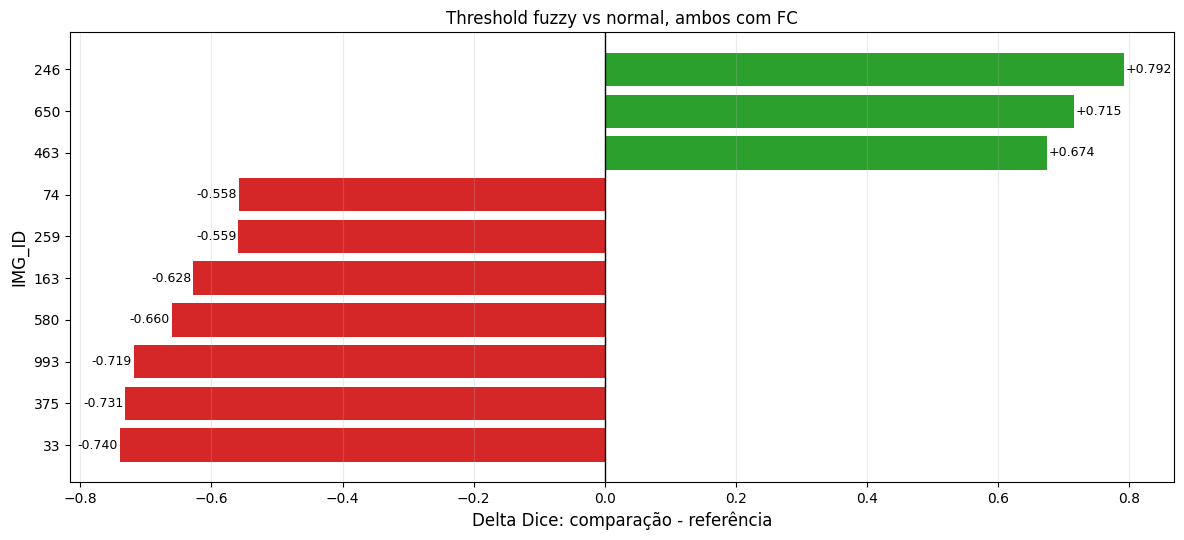

In [26]:
plot_largest_pair_changes(
    results_df,
    "normal_fc",
    "th_fuzzy_fc",
    title="Threshold fuzzy vs normal, ambos com FC",
    save_path=None,
    top_n=10,
)
plt.show()

### FC vs RG com threshold normal

In [27]:
display(pair_summary(results_df, "normal_rg", "normal_fc", PRETTY_NAMES).round({"mean_delta": 4, "median_delta": 4, "max_gain": 4, "max_loss": 4}))

,reference,comparison,n_images,mean_delta,median_delta,comparison_better_by_0_02_n,reference_better_by_0_02_n,max_gain,max_loss
0,Normal + RG,Normal + FC,700,-0.0137,-0.0077,89,212,0.3198,-0.378


In [28]:
display(largest_pair_changes(results_df, "normal_rg", "normal_fc", top_n=15).round({"reference_dice": 4, "comparison_dice": 4, "dice_delta": 4}))

,IMG_ID,reference_dice,comparison_dice,dice_delta,reference_ostia_status,comparison_ostia_status,same_ostia_points,reference_left_ostium,comparison_left_ostium,reference_right_ostium,comparison_right_ostium,reference_artery_voxels,comparison_artery_voxels
42,38,0.6969,0.3190,-0.3780,both tolerable,both tolerable,True,"(100, 155, 145)","(100, 155, 145)","(116, 120, 199)","(116, 120, 199)",18368.0,7123.0
19,386,0.5796,0.2262,-0.3534,both tolerable,both tolerable,True,"(84, 158, 105)","(84, 158, 105)","(115, 131, 164)","(115, 131, 164)",30917.0,10229.0
352,904,0.3505,0.0000,-0.3505,found but incorrect,found but incorrect,True,"(76, 129, 176)","(76, 129, 176)","(20, 101, 200)","(20, 101, 200)",14323.0,698.0
252,809,0.3542,0.0206,-0.3336,found but incorrect,found but incorrect,True,"(100, 171, 163)","(100, 171, 163)","(129, 114, 177)","(129, 114, 177)",4952.0,685.0
75,359,0.1229,0.4427,0.3198,found but incorrect,found but incorrect,True,"(116, 143, 236)","(116, 143, 236)","(66, 106, 165)","(66, 106, 165)",59333.0,6772.0
111,84,0.7388,0.4363,-0.3025,both tolerable,both tolerable,True,"(98, 172, 138)","(98, 172, 138)","(114, 135, 166)","(114, 135, 166)",30711.0,14931.0
479,632,0.2509,0.5447,0.2937,both tolerable,both tolerable,True,"(92, 138, 121)","(92, 138, 121)","(126, 117, 166)","(126, 117, 166)",157699.0,48847.0
633,745,0.3985,0.6907,0.2922,both tolerable,both tolerable,True,"(100, 178, 180)","(100, 178, 180)","(119, 141, 216)","(119, 141, 216)",15564.0,33670.0
553,15,0.4641,0.7547,0.2906,both tolerable,both tolerable,True,"(86, 136, 154)","(86, 136, 154)","(97, 101, 184)","(97, 101, 184)",14693.0,31027.0
243,818,0.7336,0.4462,-0.2874,both correct,both correct,True,"(82, 146, 185)","(82, 146, 185)","(91, 99, 205)","(91, 99, 205)",22222.0,9346.0


Figura salva em: output/segmentation/analysis/threshold_pipeline_comparison/figures/largest_changes_normal_fc_vs_normal_rg.png


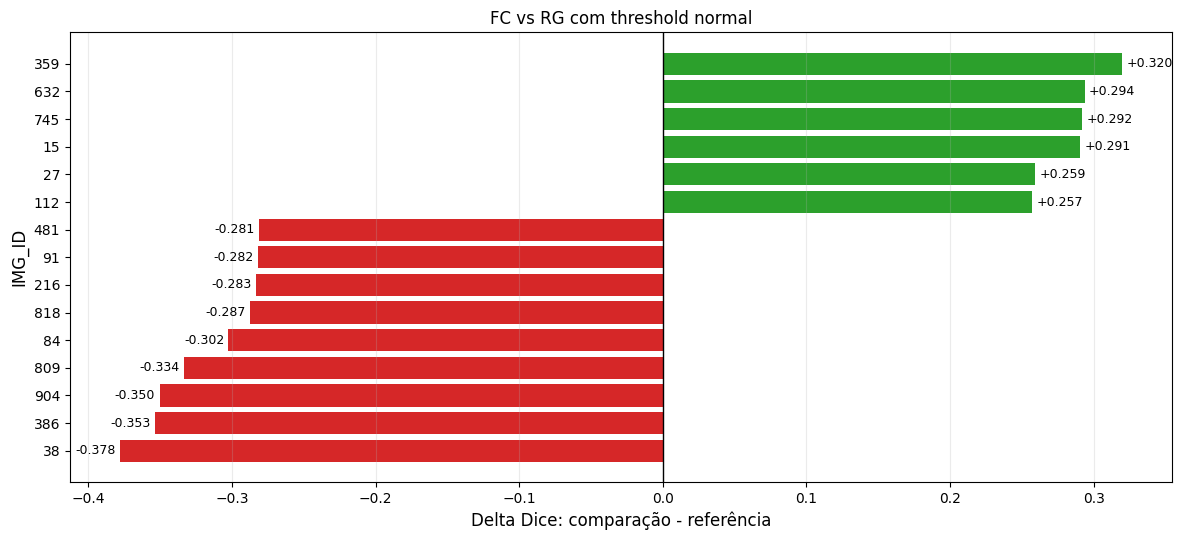

In [29]:
plot_largest_pair_changes(
    results_df,
    "normal_rg",
    "normal_fc",
    title="FC vs RG com threshold normal",
    save_path=None,
    top_n=15,
)
plt.show()

### FC vs RG com threshold fuzzy

In [30]:
display(pair_summary(results_df, "th_fuzzy_rg", "th_fuzzy_fc", PRETTY_NAMES).round({"mean_delta": 4, "median_delta": 4, "max_gain": 4, "max_loss": 4}))

,reference,comparison,n_images,mean_delta,median_delta,comparison_better_by_0_02_n,reference_better_by_0_02_n,max_gain,max_loss
0,Fuzzy threshold + RG,Fuzzy threshold + FC,700,-0.0181,-0.0076,76,224,0.496,-0.5563


In [31]:
display(largest_pair_changes(results_df, "th_fuzzy_rg", "th_fuzzy_fc", top_n=15).round({"reference_dice": 4, "comparison_dice": 4, "dice_delta": 4}))

,IMG_ID,reference_dice,comparison_dice,dice_delta,reference_ostia_status,comparison_ostia_status,same_ostia_points,reference_left_ostium,comparison_left_ostium,reference_right_ostium,comparison_right_ostium,reference_artery_voxels,comparison_artery_voxels
613,74,0.5679,0.0116,-0.5563,both tolerable,both tolerable,True,"(86, 154, 160)","(86, 154, 160)","(114, 131, 184)","(114, 131, 184)",12179.0,468.0
160,634,0.0000,0.4960,0.4960,found but incorrect,found but incorrect,True,"(114, 162, 170)","(114, 162, 170)","(103, 133, 167)","(103, 133, 167)",538.0,10044.0
589,256,0.6825,0.2360,-0.4465,both tolerable,both tolerable,True,"(83, 141, 127)","(83, 141, 127)","(97, 97, 151)","(97, 97, 151)",36057.0,7817.0
137,292,0.7336,0.3485,-0.3852,both tolerable,both tolerable,True,"(95, 163, 168)","(95, 163, 168)","(113, 136, 215)","(113, 136, 215)",29551.0,10509.0
42,38,0.6946,0.3172,-0.3774,both tolerable,both tolerable,True,"(100, 155, 145)","(100, 155, 145)","(116, 120, 199)","(116, 120, 199)",18117.0,6915.0
468,571,0.6981,0.3497,-0.3484,found but incorrect,found but incorrect,True,"(108, 146, 119)","(108, 146, 119)","(127, 121, 154)","(127, 121, 154)",47075.0,16868.0
410,563,0.2530,0.5838,0.3308,both tolerable,both tolerable,True,"(103, 161, 184)","(103, 161, 184)","(109, 125, 199)","(109, 125, 199)",4020.0,12438.0
548,630,0.5780,0.2535,-0.3246,both tolerable,both tolerable,True,"(103, 159, 173)","(103, 159, 173)","(109, 131, 195)","(109, 131, 195)",8013.0,2756.0
317,415,0.6160,0.3091,-0.3068,both tolerable,both tolerable,True,"(95, 149, 180)","(95, 149, 180)","(113, 107, 206)","(113, 107, 206)",21778.0,8179.0
111,84,0.7390,0.4364,-0.3026,both tolerable,both tolerable,True,"(98, 172, 138)","(98, 172, 138)","(114, 135, 166)","(114, 135, 166)",30662.0,14906.0


Figura salva em: output/segmentation/analysis/threshold_pipeline_comparison/figures/largest_changes_th_fuzzy_fc_vs_th_fuzzy_rg.png


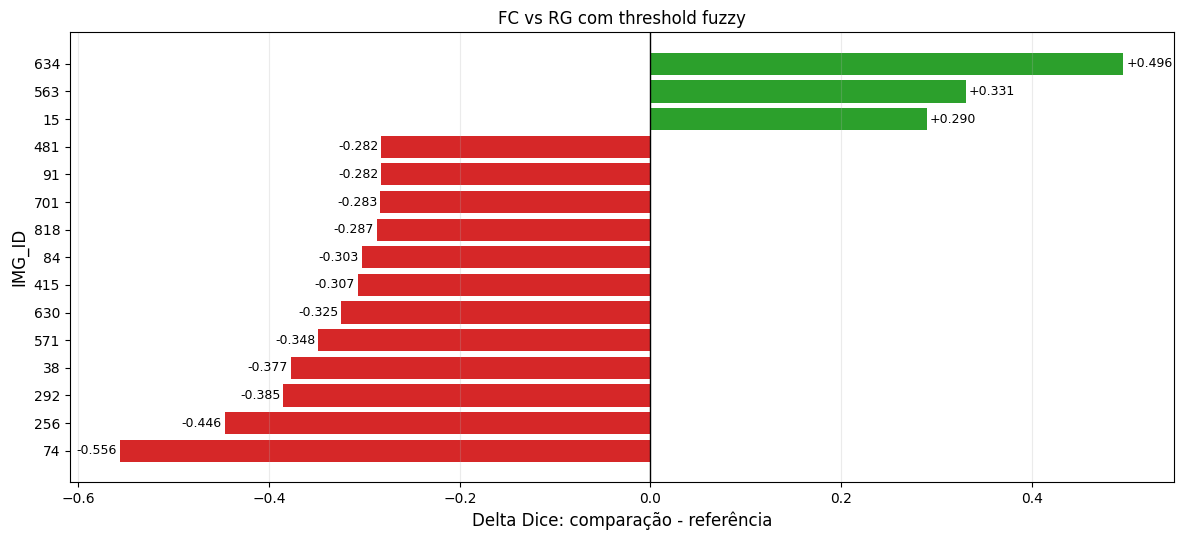

In [32]:
plot_largest_pair_changes(
    results_df,
    "th_fuzzy_rg",
    "th_fuzzy_fc",
    title="FC vs RG com threshold fuzzy",
    save_path=None,
    top_n=15,
)
plt.show()

## Melhor RG vs Melhor FC

Esta comparação seleciona automaticamente a melhor variante RG e a melhor variante FC pelo ranking geral e mostra onde o FC mais ganha ou perde em relação ao RG.

In [33]:
best_rg_variant = best_variant_by_suffix(ranking_df, "_rg")
best_fc_variant = best_variant_by_suffix(ranking_df, "_fc")
print(f"Melhor RG: {PRETTY_NAMES.get(best_rg_variant, best_rg_variant)}")
print(f"Melhor FC: {PRETTY_NAMES.get(best_fc_variant, best_fc_variant)}")

Melhor RG: Fuzzy threshold + RG
Melhor FC: Normal + FC


In [34]:
display(pair_summary(results_df, best_rg_variant, best_fc_variant, PRETTY_NAMES).round({"mean_delta": 4, "median_delta": 4, "max_gain": 4, "max_loss": 4}))

,reference,comparison,n_images,mean_delta,median_delta,comparison_better_by_0_02_n,reference_better_by_0_02_n,max_gain,max_loss
0,Fuzzy threshold + RG,Normal + FC,700,-0.0162,-0.01,108,254,0.7464,-0.7976


In [35]:
display(largest_pair_changes(results_df, best_rg_variant, best_fc_variant, top_n=10).round({"reference_dice": 4, "comparison_dice": 4, "dice_delta": 4}))

,IMG_ID,reference_dice,comparison_dice,dice_delta,reference_ostia_status,comparison_ostia_status,same_ostia_points,reference_left_ostium,comparison_left_ostium,reference_right_ostium,comparison_right_ostium,reference_artery_voxels,comparison_artery_voxels
364,246,0.7976,0.0000,-0.7976,both correct,found but incorrect,False,"(101, 163, 170)","(124, 189, 232)","(136, 139, 203)","(160, 161, 221)",28495.0,352.0
160,634,0.0000,0.7464,0.7464,found but incorrect,both tolerable,False,"(114, 162, 170)","(114, 162, 170)","(103, 133, 167)","(138, 134, 197)",538.0,18957.0
510,33,0.0000,0.7396,0.7396,found but incorrect,both tolerable,False,"(109, 160, 188)","(114, 167, 176)","(134, 129, 166)","(119, 119, 195)",1661.0,29058.0
79,375,0.0000,0.7313,0.7313,found but incorrect,both tolerable,False,"(54, 127, 262)","(107, 161, 165)","(61, 114, 263)","(116, 117, 179)",534.0,25709.0
662,993,0.0000,0.7188,0.7188,found but incorrect,both correct,False,"(71, 147, 250)","(88, 146, 173)","(70, 117, 176)","(114, 103, 200)",6009.0,41886.0
198,650,0.7079,0.0000,-0.7079,both tolerable,found but incorrect,False,"(102, 160, 147)","(124, 159, 218)","(110, 126, 179)","(107, 100, 220)",28204.0,181.0
396,463,0.6621,0.0000,-0.6621,both tolerable,found but incorrect,False,"(99, 155, 138)","(64, 161, 190)","(113, 121, 173)","(103, 143, 180)",43868.0,3309.0
201,580,0.0000,0.6601,0.6601,found but incorrect,both tolerable,False,"(89, 160, 168)","(88, 162, 155)","(84, 126, 131)","(106, 124, 185)",348.0,24349.0
139,163,0.0003,0.6280,0.6277,found but incorrect,both tolerable,False,"(90, 152, 175)","(88, 151, 164)","(108, 122, 134)","(105, 128, 211)",773.0,24508.0
335,383,0.6070,0.0000,-0.6070,both tolerable,found but incorrect,False,"(95, 152, 154)","(49, 109, 270)","(116, 114, 190)","(49, 104, 266)",17043.0,294.0


Figura salva em: output/segmentation/analysis/threshold_pipeline_comparison/figures/largest_changes_best_fc_vs_best_rg.png


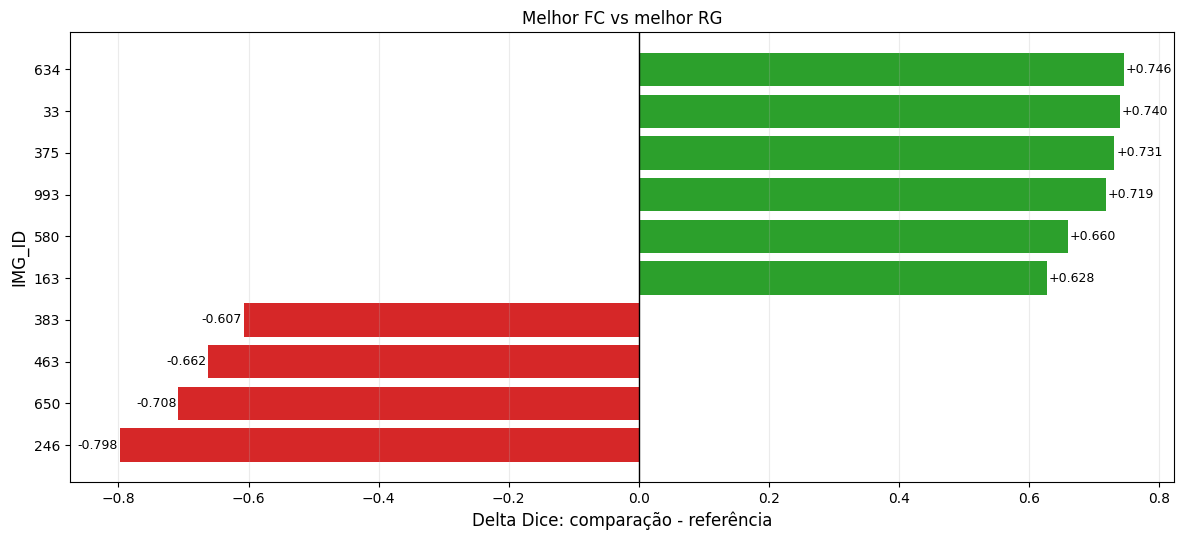

In [36]:
plot_largest_pair_changes(
    results_df,
    best_rg_variant,
    best_fc_variant,
    title="Melhor FC vs melhor RG",
    save_path=None,
    top_n=10,
)
plt.show()

## Comparação Qualitativa 3D

Esta seção compara o pipeline original (`normal_rg`) com a melhor variante encontrada no ranking. São selecionados três casos: um com status equivalente dos óstios, um com status diferente dos óstios sem Dice muito baixo nas duas máscaras, e um caso em que os Dice das duas variantes ficam próximos das médias de suas respectivas variantes. Para o status equivalente, `both correct` e `both tolerable` são tratados como o mesmo grupo de sucesso.


In [37]:

try:
    QUAL_BASE_PATH = resolve_imagecas_base_path()
except FileNotFoundError as exc:
    QUAL_BASE_PATH = None
    print(f"Dataset ImageCAS não encontrado para a análise qualitativa: {exc}")

QUAL_REFERENCE_VARIANT = baseline_variant
QUAL_COMPARISON_VARIANT = BEST_COMPARISON_VARIANT
print("Comparação qualitativa:")
print(f"  Referência: {PRETTY_NAMES.get(QUAL_REFERENCE_VARIANT, QUAL_REFERENCE_VARIANT)}")
print(f"  Variante:   {PRETTY_NAMES.get(QUAL_COMPARISON_VARIANT, QUAL_COMPARISON_VARIANT)}")


Dataset ImageCAS não encontrado para a análise qualitativa: Nenhum caminho encontrado para ImageCAS. Exporte IMAGECAS_BASE_PATH ou ajuste os candidatos:
- /media/matheus/HD/DatasetsCCTA/ImageCAS/1-1000
- /data04/home/mpmaia/ImageCAS/database/1-1000
- /home/matheus/DatasetsCCTA/ImageCAS/1-1000
Comparação qualitativa:
  Referência: Normal + RG
  Variante:   Fuzzy threshold + RG


In [38]:
QUALITATIVE_CASES, QUALITATIVE_CASES_DF = select_qualitative_pair_cases(
    results_df,
    QUAL_REFERENCE_VARIANT,
    QUAL_COMPARISON_VARIANT,
    min_dice=0.02,
    same_status_min_delta=0.0,
    same_status_max_delta=0.20,
    same_status_require_both_correct=True,
    different_status_min_delta=0.0,
    different_status_max_delta=0.30,
    different_reference_status_group="wrong",
    different_reference_one_ostium_correct=True,
    different_comparison_success=True,
    excluded_img_ids_by_case={
        "same_ostia": [70, 768],
        "different_ostia": [574, 610],
    },
)
display(QUALITATIVE_CASES_DF[[
    "case_key",
    "case_label",
    "IMG_ID",
    "reference_dice",
    "comparison_dice",
    "dice_delta",
    "same_ostia_status_group",
    "reference_status_group",
    "comparison_status_group",
    "same_ostia_points",
    "reference_one_ostium_correct",
    "comparison_ostia_success",
    "reference_both_ostia_correct_bool",
    "reference_both_ostia_tolerable_bool",
    "comparison_both_ostia_correct_bool",
    "comparison_both_ostia_tolerable_bool",
    "reference_mean_dice",
    "comparison_mean_dice",
    "reference_distance_to_mean",
    "comparison_distance_to_mean",
    "reference_ostia_status",
    "comparison_ostia_status",
    "reference_left_ostium",
    "comparison_left_ostium",
    "reference_right_ostium",
    "comparison_right_ostium",
]].round({
    "reference_dice": 4,
    "comparison_dice": 4,
    "dice_delta": 4,
    "reference_mean_dice": 4,
    "comparison_mean_dice": 4,
    "reference_distance_to_mean": 4,
    "comparison_distance_to_mean": 4,
}))


,case_key,case_label,IMG_ID,reference_dice,comparison_dice,dice_delta,same_ostia_status_group,reference_status_group,comparison_status_group,same_ostia_points,reference_one_ostium_correct,comparison_ostia_success,reference_both_ostia_correct_bool,reference_both_ostia_tolerable_bool,comparison_both_ostia_correct_bool,comparison_both_ostia_tolerable_bool,reference_mean_dice,comparison_mean_dice,reference_distance_to_mean,comparison_distance_to_mean,reference_ostia_status,comparison_ostia_status,reference_left_ostium,comparison_left_ostium,reference_right_ostium,comparison_right_ostium
0,same_ostia,Status de óstios iguais,997,0.6239,0.6892,0.0653,True,success,success,True,False,True,True,False,True,False,0.5784,0.5809,0.0454,0.1082,both correct,both correct,"(81, 162, 138)","(81, 162, 138)","(114, 117, 171)","(114, 117, 171)"
1,different_ostia,Status de óstios diferentes,327,0.4076,0.6310,0.2234,False,wrong,success,False,True,True,False,False,False,True,0.5784,0.5809,0.1708,0.0501,found but incorrect,both tolerable,"(134, 172, 152)","(108, 125, 197)","(104, 129, 195)","(128, 90, 234)"
2,near_mean,Dice próximo das médias das variantes,178,0.5809,0.5817,0.0008,True,success,success,True,True,True,False,True,False,True,0.5784,0.5809,0.0025,0.0008,both tolerable,both tolerable,"(95, 166, 139)","(95, 166, 139)","(107, 129, 180)","(107, 129, 180)"


CSV salvo em: output/segmentation/analysis/threshold_pipeline_comparison/qualitative_3d/selected_qualitative_cases.csv


In [39]:
QUALITATIVE_CACHE = {}


def load_qualitative_variant_config(variant: str) -> tuple[dict, Path]:
    run_dir = summary_df.loc[summary_df["folder_variant"] == variant, "run_dir"].iloc[0]
    config_path = REPO_ROOT / run_dir / "config/effective_pipeline_config.json"
    config = copy.deepcopy(load_config_json(str(config_path), {}))
    return config, config_path


def run_qualitative_pipeline(img_id: int, variant: str) -> dict:
    if QUAL_BASE_PATH is None:
        raise FileNotFoundError("Defina IMAGECAS_BASE_PATH para gerar os casos 3D.")
    cache_key = (int(img_id), variant)
    if cache_key not in QUALITATIVE_CACHE:
        config, config_path = load_qualitative_variant_config(variant)
        result = run_qualitative_pipeline_case(
            img_id,
            config,
            QUAL_BASE_PATH,
        )
        result.update(
            {
                "variant": variant,
                "variant_label": PRETTY_NAMES.get(variant, variant),
                "config_path": config_path,
            }
        )
        QUALITATIVE_CACHE[cache_key] = result
    return QUALITATIVE_CACHE[cache_key]


def qualitative_case_row(case_key: str) -> dict:
    return QUALITATIVE_CASES[case_key]


def display_qualitative_variant(case_key: str, variant: str) -> None:
    case = qualitative_case_row(case_key)
    img_id = int(case["IMG_ID"])
    data = run_qualitative_pipeline(img_id, variant)
    metrics = results_df.loc[
        (results_df["IMG_ID"] == img_id) & (results_df["folder_variant"] == variant),
        ["variant_label", "artery_dice", "ostia_detection_status", "left_ostium", "right_ostium", "artery_voxel_count"],
    ]
    display(metrics.round({"artery_dice": 4}))
    visualize_aorta_ostia_artery(
        data["aorta_mask"],
        data["ostia_left"],
        data["ostia_right"],
        artery_mask=data["artery_mask"],
        label_artery=data["label_artery"],
        spacing=data["scaled_spacing"],
        use_physical_coords=True,
        save_html_path=None,
        plot_name=f"{data['variant_label']} | IMG {img_id} | {case['case_label']}",
    )


### Caso com Status de Óstios Iguais

`both correct` e `both tolerable` são considerados o mesmo grupo de sucesso nesta seleção.


In [40]:
print("Pipeline original")
display_qualitative_variant("same_ostia", QUAL_REFERENCE_VARIANT)


Pipeline original


FileNotFoundError: Defina IMAGECAS_BASE_PATH para gerar os casos 3D.

In [ ]:
print("Melhor variante")
display_qualitative_variant("same_ostia", QUAL_COMPARISON_VARIANT)


Melhor variante
Parada na fatia 129: Δr=4.00 ou dist=37.54


,variant_label,artery_dice,ostia_detection_status,left_ostium,right_ostium,artery_voxel_count
2499,Fuzzy threshold + RG,0.6892,both correct,"(81, 162, 138)","(114, 117, 171)",39105.0


Output()

HTML salvo em: output/segmentation/analysis/threshold_pipeline_comparison/qualitative_3d/same_ostia_th_fuzzy_rg_img_997_aorta_ostia_artery.html


### Caso com Status de Óstios Diferentes


In [ ]:
print("Pipeline original")
display_qualitative_variant("different_ostia", QUAL_REFERENCE_VARIANT)


Pipeline original
Parada na fatia 154: Δr=5.00 ou dist=42.38


,variant_label,artery_dice,ostia_detection_status,left_ostium,right_ostium,artery_voxel_count
876,Normal + RG,0.4076,found but incorrect,"(134, 172, 152)","(104, 129, 195)",10762.0


Output()

HTML salvo em: output/segmentation/analysis/threshold_pipeline_comparison/qualitative_3d/different_ostia_normal_rg_img_327_aorta_ostia_artery.html


In [ ]:
print("Melhor variante")
display_qualitative_variant("different_ostia", QUAL_COMPARISON_VARIANT)


Melhor variante
Parada na fatia 186: Δr=0.00 ou dist=35.47


,variant_label,artery_dice,ostia_detection_status,left_ostium,right_ostium,artery_voxel_count
2276,Fuzzy threshold + RG,0.631,both tolerable,"(108, 125, 197)","(128, 90, 234)",20578.0


Output()

HTML salvo em: output/segmentation/analysis/threshold_pipeline_comparison/qualitative_3d/different_ostia_th_fuzzy_rg_img_327_aorta_ostia_artery.html


### Caso Próximo das Médias


In [ ]:
print("Pipeline original")
display_qualitative_variant("near_mean", QUAL_REFERENCE_VARIANT)


Pipeline original
Parada na fatia 137: Δr=0.00 ou dist=34.99


,variant_label,artery_dice,ostia_detection_status,left_ostium,right_ostium,artery_voxel_count
797,Normal + RG,0.5809,both tolerable,"(95, 166, 139)","(107, 129, 180)",22146.0


Output()

HTML salvo em: output/segmentation/analysis/threshold_pipeline_comparison/qualitative_3d/near_mean_normal_rg_img_178_aorta_ostia_artery.html


In [ ]:
print("Melhor variante")
display_qualitative_variant("near_mean", QUAL_COMPARISON_VARIANT)


Melhor variante
Parada na fatia 137: Δr=0.00 ou dist=34.99


,variant_label,artery_dice,ostia_detection_status,left_ostium,right_ostium,artery_voxel_count
2197,Fuzzy threshold + RG,0.5817,both tolerable,"(95, 166, 139)","(107, 129, 180)",22002.0


Output()

HTML salvo em: output/segmentation/analysis/threshold_pipeline_comparison/qualitative_3d/near_mean_th_fuzzy_rg_img_178_aorta_ostia_artery.html


## Conclusão

O ranking, as comparações pareadas e os casos 3D permitem escolher a variante com melhor desempenho sem perder de vista falhas específicas por exame.